# CNN Classification Apparel (ResNet-50 Architecture)

## Imports

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

### Set random seed for reproducibility

In [18]:
torch.manual_seed(42)
np.random.seed(42)

### Check GPU availability

In [19]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Model Settings

In [20]:
##########################
### SETTINGS
##########################

# Hyperparameters
LEARNING_RATE = 0.001
BATCH_SIZE = 32  # Reduced for CPU  (recomended using GPU)
NUM_EPOCHS = 10  # Reduced for demonstration

# Dataset settings
NUM_CLASSES = 5  # For your 5 clothing classes
GRAYSCALE = False  # Assuming color images

# Dataset

In [21]:
##########################
### DATA PREPARATION
##########################

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
try:
    train_dataset = ImageFolder(root='clothing_dataset/train', transform=transform)
    test_dataset = ImageFolder(root='clothing_dataset/test', transform=transform)
    
    print(f"Classes: {train_dataset.classes}")
    print(f"Number of training images: {len(train_dataset)}")
    print(f"Number of test images: {len(test_dataset)}")
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Create dummy datasets if real data not available
    from torchvision.datasets import FakeData
    train_dataset = FakeData(size=1000, image_size=(3, 224, 224), num_classes=NUM_CLASSES, transform=transform)
    test_dataset = FakeData(size=200, image_size=(3, 224, 224), num_classes=NUM_CLASSES, transform=transform)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Classes: ['dress', 'pant', 'shoes', 'shrit']
Number of training images: 100
Number of test images: 20


### Visualize sample images

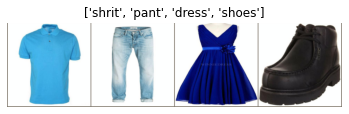

In [22]:
def imshow(img, title=None):
    """Imshow for Tensor."""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
images, labels = next(iter(train_loader))

# Make a grid from batch
sample_images = torchvision.utils.make_grid(images[:4])

# Show images with labels
imshow(sample_images, title=[train_dataset.classes[x] for x in labels[:4]])
plt.show()

# Resnet50 Model

In [23]:
##########################
### RESNET-50 MODEL
##########################

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes, grayscale):
        self.inplanes = 64
        in_dim = 1 if grayscale else 3
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_dim, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

# Create model
model = ResNet(block=Bottleneck, layers=[3, 4, 6, 3], num_classes=NUM_CLASSES, grayscale=GRAYSCALE)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training

In [26]:
##########################
### TRAINING
##########################

def train_model(model, criterion, optimizer, num_epochs):
    since = time.time()
    
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = test_loader
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)
        
        print()
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

# Train the model
model, train_loss, val_loss, train_acc, val_acc = train_model(model, criterion, optimizer, NUM_EPOCHS)



Epoch 0/9
----------
train Loss: 2.5358 Acc: 0.2600
val Loss: 1.4520 Acc: 0.4000

Epoch 1/9
----------
train Loss: 1.3194 Acc: 0.4800
val Loss: 1.6179 Acc: 0.2500

Epoch 2/9
----------
train Loss: 0.9210 Acc: 0.5900
val Loss: 1.8201 Acc: 0.3000

Epoch 3/9
----------
train Loss: 0.6067 Acc: 0.7600
val Loss: 2.5779 Acc: 0.2500

Epoch 4/9
----------
train Loss: 1.5068 Acc: 0.6100
val Loss: 1.2281 Acc: 0.7000

Epoch 5/9
----------
train Loss: 1.0852 Acc: 0.6700
val Loss: 4.2870 Acc: 0.6500

Epoch 6/9
----------
train Loss: 0.8967 Acc: 0.5800
val Loss: 7.4302 Acc: 0.5500

Epoch 7/9
----------
train Loss: 0.7433 Acc: 0.6800
val Loss: 3.7328 Acc: 0.5500

Epoch 8/9
----------
train Loss: 0.5950 Acc: 0.7400
val Loss: 1.3044 Acc: 0.8000

Epoch 9/9
----------
train Loss: 0.5814 Acc: 0.7700
val Loss: 0.7938 Acc: 0.8000

Training complete in 6m 45s
Best val Acc: 0.800000


### Plot Training History

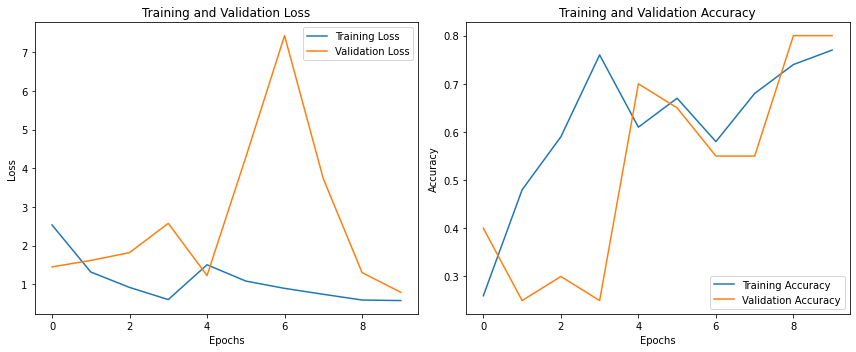

In [27]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluation

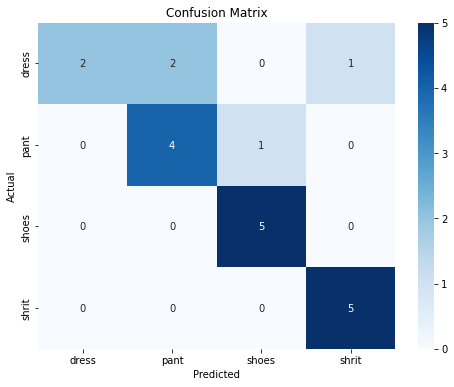

In [28]:
##########################
### EVALUATION
##########################

def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    return y_true, y_pred

# Get predictions
y_true, y_pred = evaluate_model(model, test_loader)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_dataset.classes, 
            yticklabels=train_dataset.classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Classification report

In [29]:

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


Classification Report:
              precision    recall  f1-score   support

       dress       1.00      0.40      0.57         5
        pant       0.67      0.80      0.73         5
       shoes       0.83      1.00      0.91         5
       shrit       0.83      1.00      0.91         5

    accuracy                           0.80        20
   macro avg       0.83      0.80      0.78        20
weighted avg       0.83      0.80      0.78        20



### Calculate additional metrics

In [30]:

report = classification_report(y_true, y_pred, target_names=train_dataset.classes, output_dict=True)
precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']
accuracy = report['accuracy']

print(f"\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Accuracy: 0.8000
Precision: 0.8333
Recall: 0.8000
F1-Score: 0.7792


#  Save Model

In [31]:
##########################
### SAVE MODEL
##########################

torch.save(model.state_dict(), 'resnet50_clothing_classifier.pth')
print("Model saved to resnet50_clothing_classifier.pth")

Model saved to resnet50_clothing_classifier.pth


### Cek Model

In [32]:
data = torch.load("resnet50_clothing_classifier.pth", map_location="cpu")

print(type(data))  # bisa dict, OrderedDict, model instance
if isinstance(data, dict):
    print("Keys:", data.keys())


<class 'collections.OrderedDict'>
Keys: odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight', 'layer1.0.bn3.bias', 'layer1.0.bn3.running_mean', 'layer1.0.bn3.running_var', 'layer1.0.bn3.num_batches_tracked', 'layer1.0.downsample.0.weight', 'layer1.0.downsample.1.weight', 'layer1.0.downsample.1.bias', 'layer1.0.downsample.1.running_mean', 'layer1.0.downsample.1.running_var', 'layer1.0.downsample.1.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.

<ipython-input-32-f1febcc54a9d>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("resnet50_clothing_classifier.pth", map_location="cpu")
